## Cell 1: Chuẩn bị dữ liệu

In [1]:
import os
import glob
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# 1. TỰ ĐỘNG TÌM DATA_PATH
DATA_PATH = os.path.abspath('../../data/processed')
print(f"✅ Đã tìm thấy DATA_PATH: {DATA_PATH}")

# 2. ĐỌC LABEL MAP
label_map_path = os.path.join(DATA_PATH, "label_map.json")
with open(label_map_path, 'r', encoding='utf-8') as f:
    label_map = json.load(f)

NUM_CLASSES = len(label_map)
print(f"Tổng số lớp: {NUM_CLASSES}")

# 3. ĐỊNH NGHĨA DATASET
class VSL400KeypointDataset3D(Dataset):
    def __init__(self, npz_path, max_len=60):
        data = np.load(npz_path, allow_pickle=True)
        self.X = data['X']
        self.y = np.array(data['y'], dtype=np.int64)
        self.max_len = max_len

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x_sample = np.array(self.X[idx], dtype=np.float32)
        seq_len = x_sample.shape[0]
        spatial_shape = x_sample.shape[1:]

        if seq_len >= self.max_len:
            x_padded = x_sample[:self.max_len]
        else:
            padded_shape = (self.max_len,) + spatial_shape
            x_padded = np.zeros(padded_shape, dtype=np.float32)
            x_padded[:seq_len] = x_sample

        return torch.from_numpy(x_padded), torch.tensor(self.y[idx], dtype=torch.long)

# 4. NẠP DATALOADER (Đặt num_workers=0 để tránh lỗi BrokenPipeError trong Jupyter)
MAX_SEQ_LEN = 60
train_dataset = VSL400KeypointDataset3D(os.path.join(DATA_PATH, "f1_train.npz"), max_len=MAX_SEQ_LEN)
val_dataset   = VSL400KeypointDataset3D(os.path.join(DATA_PATH, "f1_val.npz"), max_len=MAX_SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ Đã chuẩn bị DataLoader xong!")

✅ Đã tìm thấy DATA_PATH: /home/john-vx/year-3-autumn-term/Multimodal-Recognition-and-Translation-of-Vietnamese-Sign-Language-to-Text-and-Speech/data/processed
Tổng số lớp: 400
✅ Đã chuẩn bị DataLoader xong!


## Cell 2: Định nghĩa và Huấn luyện GRU

Thiết bị: cuda

🚀 Bắt đầu huấn luyện mô hình GRU...


Epoch 01/30 [Train]:   0%|          | 0/271 [00:00<?, ?it/s]

Epoch 01/30 | Train Loss: 4.8808 - Train Acc: 6.64% | Val Loss: 3.4584 - Val Acc: 19.82%
  --> [Saved Model] Đạt Val Acc cao nhất: 19.82%


Epoch 02/30 [Train]:   0%|          | 0/271 [00:00<?, ?it/s]

Epoch 02/30 | Train Loss: 2.6682 - Train Acc: 36.41% | Val Loss: 1.8207 - Val Acc: 55.37%
  --> [Saved Model] Đạt Val Acc cao nhất: 55.37%


...

Epoch 28/30 | Train Loss: 0.0283 - Train Acc: 99.17% | Val Loss: 0.5999 - Val Acc: 88.93%
  --> [Saved Model] Đạt Val Acc cao nhất: 88.93%


Epoch 29/30 [Train]:   0%|          | 0/271 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 0.0244 - Train Acc: 99.30% | Val Loss: 0.5970 - Val Acc: 88.74%


Epoch 30/30 [Train]:   0%|          | 0/271 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 0.0201 - Train Acc: 99.50% | Val Loss: 0.6238 - Val Acc: 88.45%


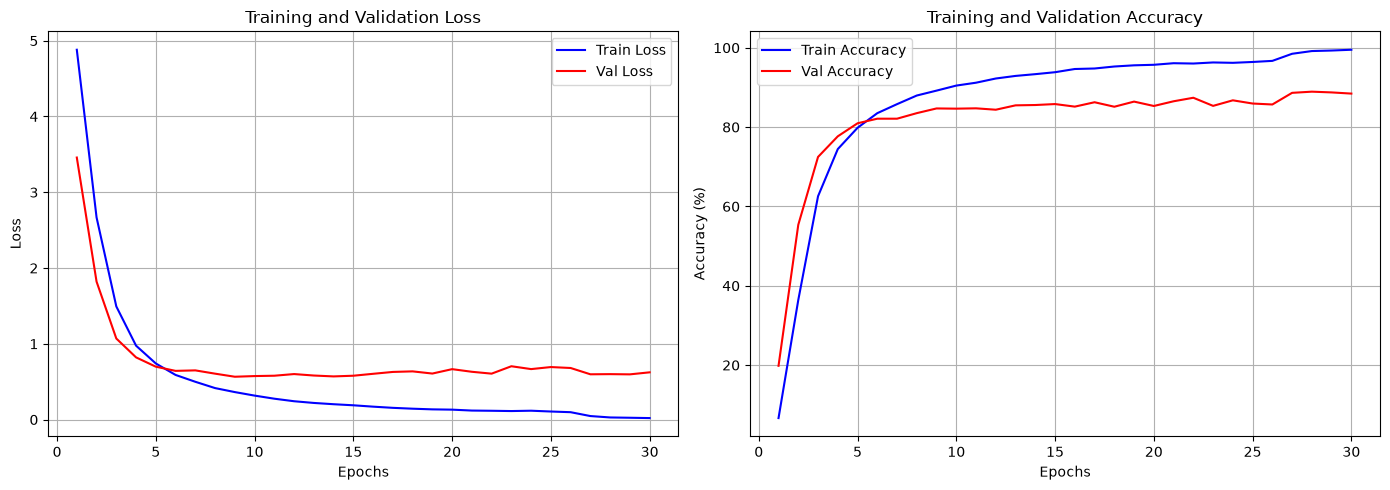

In [3]:
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị: {DEVICE}")

class VSL400GRU(nn.Module):
    def __init__(self, num_joints=76, coords=3, hidden_size=256, num_classes=400):
        super().__init__()
        input_size = num_joints * coords
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        batch_size, seq_len = x.shape[0], x.shape[1]
        x = x.view(batch_size, seq_len, -1)
        
        out, _ = self.gru(x)
        out = out[:, -1, :] 
        return self.fc(out)

# Khởi tạo Mô hình
model = VSL400GRU(num_joints=76, coords=3, hidden_size=256, num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# Huấn luyện
EPOCHS = 30
best_acc = 0.0
SAVE_PATH = "30ep/best_gru_vsl400.pth"

# Lưu dữ liệu để vẽ biểu đồ
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n🚀 Bắt đầu huấn luyện mô hình GRU...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]"):
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(dim=-1)
        correct_train += (preds == y_batch).sum().item()
        total_train += y_batch.size(0)

    train_acc = 100 * correct_train / total_train
    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)

            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()
            preds = outputs.argmax(dim=-1)
            correct_val += (preds == y_batch).sum().item()
            total_val += y_batch.size(0)

    val_acc = 100 * correct_val / total_val
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(val_acc)

    # Thêm dữ liệu vào history
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} - Train Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  --> [Saved Model] Đạt Val Acc cao nhất: {best_acc:.2f}%")

# Vẽ biểu đồ Learning Curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history['train_loss'], label='Train Loss', color='blue')
plt.plot(range(1, EPOCHS + 1), history['val_loss'], label='Val Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), history['train_acc'], label='Train Accuracy', color='blue')
plt.plot(range(1, EPOCHS + 1), history['val_acc'], label='Val Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Cell 3: Đánh giá tập Test

✅ Đã nạp thành công weights từ: 30ep/best_gru_vsl400.pth


Testing:   0%|          | 0/59 [00:00<?, ?it/s]


📊 KẾT QUẢ TẬP TEST (f1_test.npz)
Tổng số mẫu test:   3713
Test Loss:          0.5933
Test Accuracy:      88.74%

🔍 XEM THỬ 10 DỰ ĐOÁN MẪU:
1     | Thực tế: Không cần                      | Dự đoán: Đắng                           | ❌ SAI
2     | Thực tế: Bia                            | Dự đoán: Bia                            | ✅ ĐÚNG
3     | Thực tế: Buổi chiều                     | Dự đoán: Buổi chiều                     | ✅ ĐÚNG
4     | Thực tế: Đi                             | Dự đoán: Đi                             | ✅ ĐÚNG
5     | Thực tế: Kế toán                        | Dự đoán: Kế toán                        | ✅ ĐÚNG
6     | Thực tế: Cô                             | Dự đoán: Cô                             | ✅ ĐÚNG
7     | Thực tế: Viên phấn                      | Dự đoán: Viên phấn                      | ✅ ĐÚNG
8     | Thực tế: Nhầm lẫn                       | Dự đoán: Nhầm lẫn                       | ✅ ĐÚNG
9     | Thực tế: Dây chuyền                     | Dự đoán: Dây chuyền

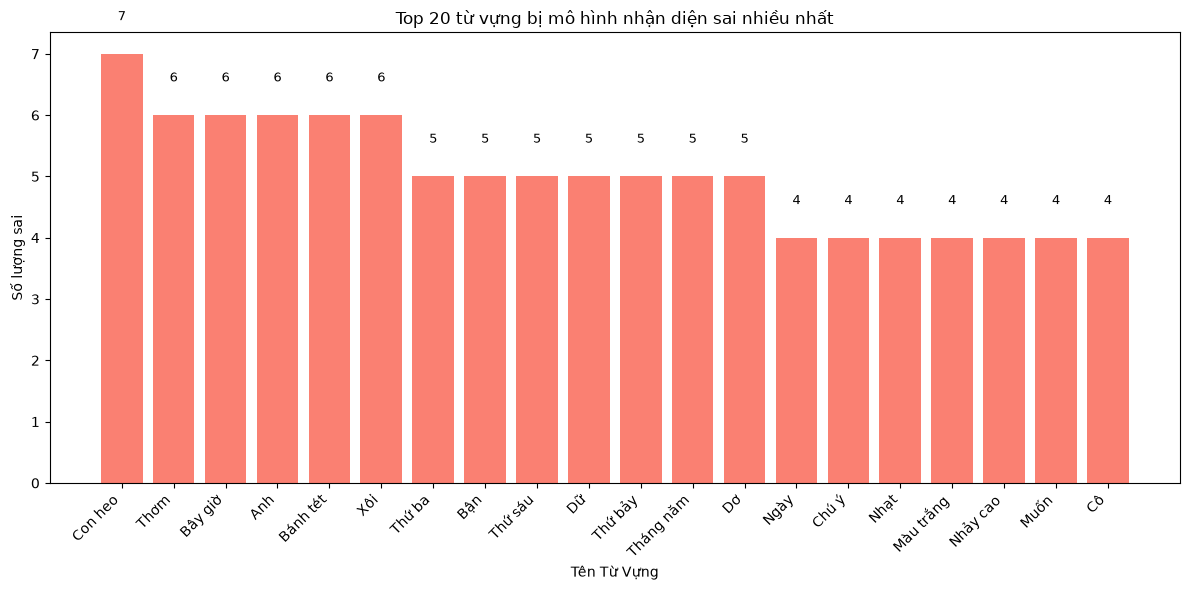

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

# 5. NẠP TẬP TEST & ĐÁNH GIÁ
test_dataset = VSL400KeypointDataset3D(os.path.join(DATA_PATH, "f2_test.npz"), max_len=MAX_SEQ_LEN)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

eval_model = VSL400GRU(num_joints=76, coords=3, hidden_size=256, num_classes=NUM_CLASSES).to(DEVICE)

if os.path.exists(SAVE_PATH):
    eval_model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
    print(f"✅ Đã nạp thành công weights từ: {SAVE_PATH}")
else:
    print(f"❌ KHÔNG tìm thấy file model tại {SAVE_PATH}.")

criterion = nn.CrossEntropyLoss()
eval_model.eval()

test_loss = 0.0
correct = 0
total = 0
all_preds = []
all_targets = []
errors = []

with torch.no_grad():
    for x_batch, y_batch in tqdm(test_loader, desc="Testing"):
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        
        outputs = eval_model(x_batch)
        loss = criterion(outputs, y_batch)
        
        test_loss += loss.item()
        preds = outputs.argmax(dim=-1)
        
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
        
        preds_cpu = preds.cpu().numpy()
        targets_cpu = y_batch.cpu().numpy()
        all_preds.extend(preds_cpu)
        all_targets.extend(targets_cpu)
        
        # Thu thập các lớp nhận diện sai
        for p, t in zip(preds_cpu, targets_cpu):
            if p != t:
                errors.append(t)

test_acc = 100 * correct / total
avg_test_loss = test_loss / len(test_loader)

print("\n" + "="*50)
print(f"📊 KẾT QUẢ TẬP TEST (f1_test.npz)")
print("="*50)
print(f"Tổng số mẫu test:   {total}")
print(f"Test Loss:          {avg_test_loss:.4f}")
print(f"Test Accuracy:      {test_acc:.2f}%")
print("="*50)

if isinstance(label_map, dict):
    idx_to_label = {v: k for k, v in label_map.items()}
else:
    idx_to_label = {i: name for i, name in enumerate(label_map)}

print("\n🔍 XEM THỬ 10 DỰ ĐOÁN MẪU:")
for i in range(min(10, len(all_preds))):
    actual_name = idx_to_label.get(all_targets[i], f"Class {all_targets[i]}")
    pred_name   = idx_to_label.get(all_preds[i], f"Class {all_preds[i]}")
    status      = "✅ ĐÚNG" if all_targets[i] == all_preds[i] else "❌ SAI"
    
    print(f"{i+1:<5} | Thực tế: {actual_name:<30} | Dự đoán: {pred_name:<30} | {status}")

# Vẽ biểu đồ thống kê lỗi phân loại
error_counts = Counter(errors)
top_errors = error_counts.most_common(20)

if top_errors:
    labels = [idx_to_label.get(idx, f"Class {idx}") for idx, count in top_errors]
    counts = [count for idx, count in top_errors]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, counts, color='salmon')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Tên Từ Vựng')
    plt.ylabel('Số lượng sai')
    plt.title('Top 20 từ vựng bị mô hình nhận diện sai nhiều nhất')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=9)
        
    plt.tight_layout()
    plt.show()
else:
    print("\nMô hình không có lỗi phân loại trong tập dữ liệu kiểm thử.")